In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, time

In [25]:
data = []

now = time.time()
for file in os.listdir('.'):
    if file.endswith('_power_events.csv'):
        df = pd.read_csv(file)
        df['t'] = pd.to_datetime(df['time'] + now, unit='s')
        df.set_index('t', inplace=True)
        data.append(df)

In [26]:
data[0]

,time,power,energy
t,,,
2026-01-23 12:17:43.736134052,3.096644,0.000001,0.000000e+00
2026-01-23 12:17:43.736135244,3.096645,0.279544,1.000000e-12
2026-01-23 12:17:43.767112017,3.127622,0.000001,8.659436e-03
2026-01-23 12:17:43.767113209,3.127623,0.072132,8.659436e-03
2026-01-23 12:17:44.167213202,3.527723,0.000000,3.751938e-02
2026-01-23 12:17:48.717345238,8.077855,0.000001,3.751938e-02
2026-01-23 12:17:48.717346191,8.077856,0.279544,3.751938e-02
2026-01-23 12:17:48.748323202,8.108833,0.000001,4.617881e-02
2026-01-23 12:17:48.748324156,8.108834,0.072132,4.617881e-02


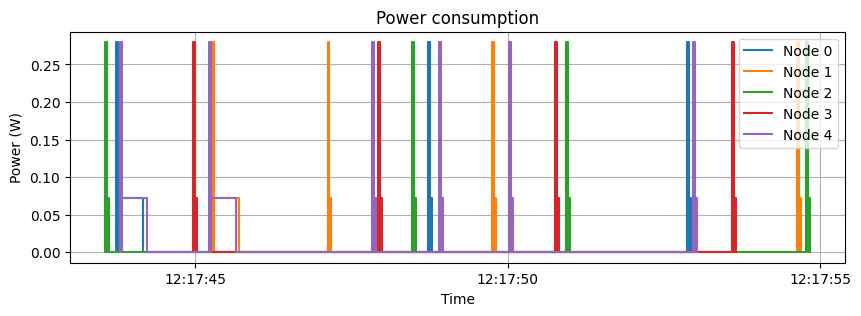

In [27]:
fig, ax = plt.subplots(figsize=(10, 3))

ax.grid()

for i, df in enumerate(data):
    ax.step(
        df.index, 
        df['power'], 
        where='post',
        label=f'Node {i}'
    )

ax.set_title('Power consumption')
ax.set_xlabel('Time')
ax.set_ylabel('Power (W)')
ax.legend(loc='upper right')

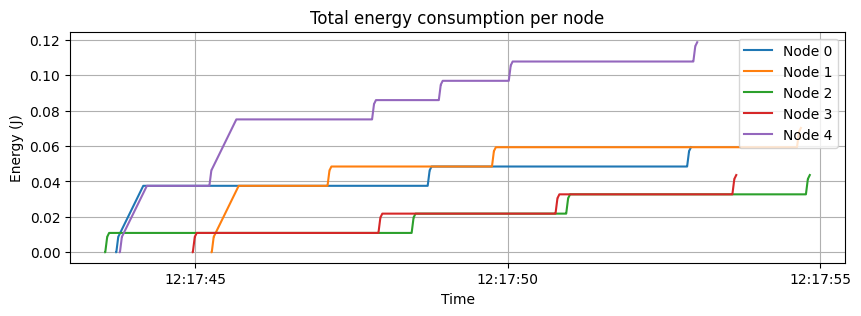

In [28]:
fig, ax = plt.subplots(figsize=(10, 3))

ax.grid()

for i, df in enumerate(data):
    ax.plot(
        df.index, 
        df['energy'], 
        label=f'Node {i}'
    )

ax.set_title('Total energy consumption per node')
ax.set_xlabel('Time')
ax.set_ylabel('Energy (J)')
ax.legend(loc='upper right')